## Modele de prediction:


1.	collecte des données
Pour cela on va utiliser la base de données de Kaggle.

- importation des packages
Pandas:  car permet de manipuler les données sous forme de tableau: fusionner, importer etc...
Numpy:  car permet de faire des calcules mathematiques sur des tableaux  et des matrices
Matplotlib et Seaborn: pour la visualisation sous forme graphique
Pickle : pour generer le modèle car on va deploier notre modèle dans une application

2.	Nettoyage de la base de données (data cleaning)

On essaye de voir les données manquantes car ça peut faussé les resultats

En affichant la base de donnée df, on remarque que notre df à 614 lignes et 13 colonnes.Mais par defaut on voit que 10 lignes.
Pour afficher toutes les lignes, on fait appelle l'option display
Pour reduire la taille de df à  10 on fait appelle à set_option
Maintenant qu'on a notre base de données df, pour avoir des renseignement sur les valeurs manaquantes on peut faire appelle à : info

- Renseigner les valeurs manaquantes: pour cela on va créer deux listes:  une liste categiruques et une liste numerique
    - Pour les variables categoriques, on va remplacer les données manquantes par les valeurs qui se repète le plus
    - Pour les variables numeriques on va remplacer les données manquantes par les valeurs par la valeurs precedantes de la 
      même colonne
- Transformer la target
    - Le target est Loan_Status, on va changer les données du target par 1 et 0
    - Pour cela on va créer un dictionnaire appeler target_value
  
3.	Analyse exploratoire :
On utilise la visualisation on comprendre notre base de données.


4.	Préparation du modèle du machine learning

On va evaluer trois modèle d'algorithme:on est dans un problème de classification
- Regression logistique(est le meilleur modèle suite à la comparaison des trois modèle
- KNN
- DecissionTree
Ensuite on choisit 5 variable pour la modelisation avec l'algorithme de la regression logistique: 'Credit_History','Gender', 'Married','CoapplicantIncome'et 'ApplicantIncome'
5.	Déploiement du modèle
On va intégrer notre modèle dans une application ou une application Web en utilisant un micro-framework (FLASK) utilisable par une personne non technique pour avoir des infos 

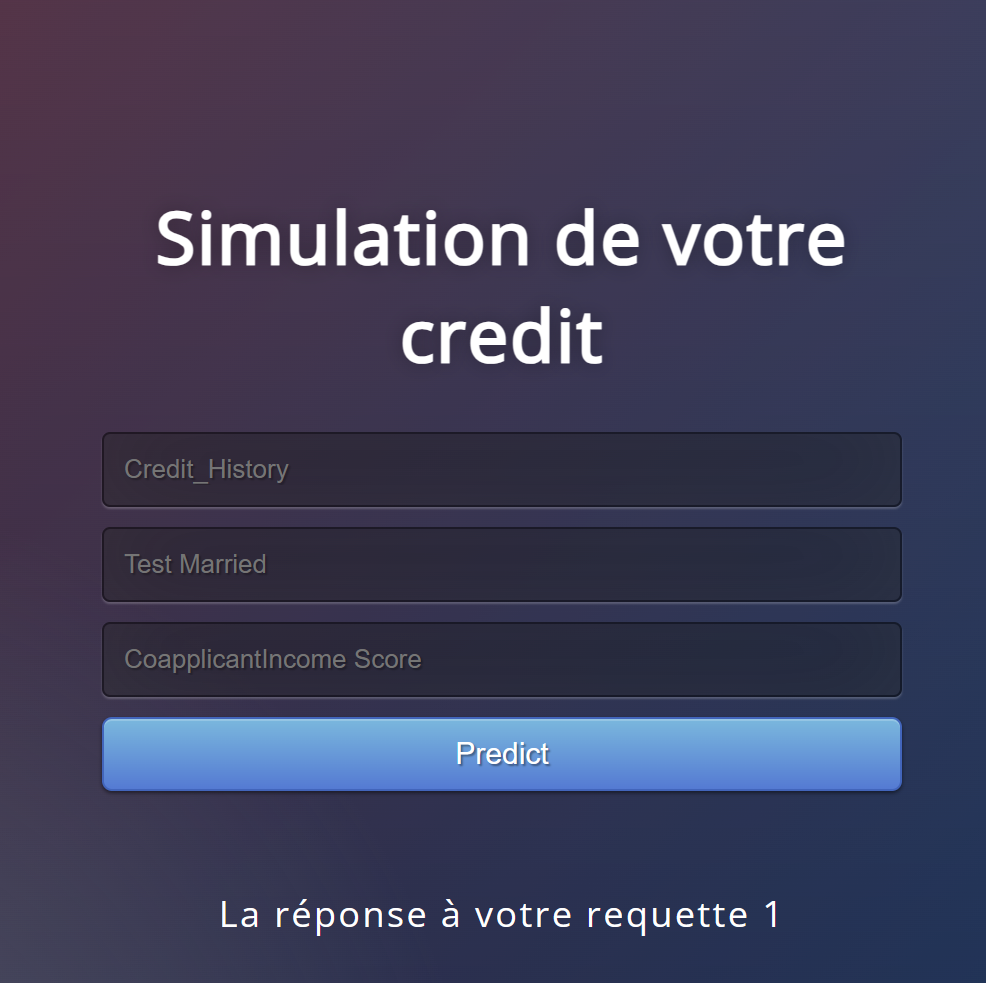


In [56]:
# importation des packages
# Pandas:  car permet de manipuler les données sous forme de tableau: fusionner, importer etc...
# Numpy:  car permet de faire des calcules mathematiques sur des tableaux  et des matrices
# Matplotlib et Seaborn: pour la visualisation sous forme graphique
# Pickle : pour generer le modèle car on va deploier notre modèle dans une application
# sklearn (LabelEncoder): automatiser l'encodage des variable categorique
# sklearn (StratifiedShuffleSplit): pour diviser notre base de donnée en train et test
#sklearn (LogisticRegression): pour le modèle de regression logistique
#sklearn (KNeighborsClassifier): pour le modèle knn les k les plus proches voisin
#sklearn (DecisionTreeClassifier): pour le modèle DecisionTreeClassifier
#sklearn.metrics(accuracy_score): pour evaluer les modèles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pickle as pe


In [2]:
# Lecture de la base de données
df=pd.read_csv("train.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


- En affichant la base de donnée df, on remarque que notre df à  614 lignes et 13 colonnes.Mais par defaut on voit que 10 lignes.
- Pour afficher toutes les lignes, on fait appelle l'option display

In [3]:
pd.set_option("display.max_rows",df.shape[0]+1)
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.000000,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.000000,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.000000,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.000000,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.000000,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.000000,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.000000,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.000000,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.000000,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.000000,349.0,360.0,1.0,Semiurban,N


- Pour reduire la taille de df à  10 on fait appelle à set_option

In [4]:
pd.set_option("display.max_rows",10)
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


- Maintenant qu'on a notre base de données df, pour avoir des renseignement sur les valeurs manaquantes on peut faire appelle à : info

## 1.Valeurs manquantes

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
df.isnull().sum().sort_values(ascending=False)

Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
                     ..
Education             0
ApplicantIncome       0
CoapplicantIncome     0
Property_Area         0
Loan_Status           0
Length: 13, dtype: int64

## 2 Les outlayer

In [7]:
# Pour valeurs numeriques
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
df.describe(include='O')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


- Comme type de données on a : float64(4), int64(1), object(8)
- Loan_Amount_Term,LoanAmount,Dependents et Self_Employed, Credit_History ont beaucoup de valeurs manquantes
- Pour voir les valeurs mal renseigner outlayer, on peut faire appelle à descibe pour voir les donnes statistiques numeriques
  on observe pas de valeurs negatives, on peut dire que les valeurs sont correctes 

In [9]:
df.dtypes

Loan_ID              object
Gender               object
Married              object
Dependents           object
Education            object
                     ...   
LoanAmount          float64
Loan_Amount_Term    float64
Credit_History      float64
Property_Area        object
Loan_Status          object
Length: 13, dtype: object

## Renseigner les valeurs manaquantes

In [10]:
## Renseigner les valeurs manaquantes
cat_data=[]
num_data=[]

for i,c in enumerate(df.dtypes):
    if c==object:
        cat_data.append(df.iloc[:,i])
    else:
        num_data.append(df.iloc[:,i])

In [11]:
cat_data

[0      LP001002
 1      LP001003
 2      LP001005
 3      LP001006
 4      LP001008
          ...   
 609    LP002978
 610    LP002979
 611    LP002983
 612    LP002984
 613    LP002990
 Name: Loan_ID, Length: 614, dtype: object,
 0        Male
 1        Male
 2        Male
 3        Male
 4        Male
         ...  
 609    Female
 610      Male
 611      Male
 612      Male
 613    Female
 Name: Gender, Length: 614, dtype: object,
 0       No
 1      Yes
 2      Yes
 3      Yes
 4       No
       ... 
 609     No
 610    Yes
 611    Yes
 612    Yes
 613     No
 Name: Married, Length: 614, dtype: object,
 0       0
 1       1
 2       0
 3       0
 4       0
        ..
 609     0
 610    3+
 611     1
 612     2
 613     0
 Name: Dependents, Length: 614, dtype: object,
 0          Graduate
 1          Graduate
 2          Graduate
 3      Not Graduate
 4          Graduate
            ...     
 609        Graduate
 610        Graduate
 611        Graduate
 612        Graduate
 613   

In [12]:
num_data

[0      5849
 1      4583
 2      3000
 3      2583
 4      6000
        ... 
 609    2900
 610    4106
 611    8072
 612    7583
 613    4583
 Name: ApplicantIncome, Length: 614, dtype: int64,
 0         0.0
 1      1508.0
 2         0.0
 3      2358.0
 4         0.0
         ...  
 609       0.0
 610       0.0
 611     240.0
 612       0.0
 613       0.0
 Name: CoapplicantIncome, Length: 614, dtype: float64,
 0        NaN
 1      128.0
 2       66.0
 3      120.0
 4      141.0
        ...  
 609     71.0
 610     40.0
 611    253.0
 612    187.0
 613    133.0
 Name: LoanAmount, Length: 614, dtype: float64,
 0      360.0
 1      360.0
 2      360.0
 3      360.0
 4      360.0
        ...  
 609    360.0
 610    180.0
 611    360.0
 612    360.0
 613    360.0
 Name: Loan_Amount_Term, Length: 614, dtype: float64,
 0      1.0
 1      1.0
 2      1.0
 3      1.0
 4      1.0
       ... 
 609    1.0
 610    1.0
 611    1.0
 612    1.0
 613    0.0
 Name: Credit_History, Length: 614, dtype: f

In [13]:
# on va transformer les deux listes en base de données
cat_data=pd.DataFrame(cat_data)
num_data=pd.DataFrame(num_data)

In [14]:
cat_data

,0,1,2,3,4,5,6,7,8,9,...,604,605,606,607,608,609,610,611,612,613
Loan_ID,LP001002,LP001003,LP001005,LP001006,LP001008,LP001011,LP001013,LP001014,LP001018,LP001020,...,LP002959,LP002960,LP002961,LP002964,LP002974,LP002978,LP002979,LP002983,LP002984,LP002990
Gender,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,...,Female,Male,Male,Male,Male,Female,Male,Male,Male,Female
Married,No,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No
Dependents,0,1,0,0,0,2,0,3+,2,1,...,1,0,1,2,0,0,3+,1,2,0
Education,Graduate,Graduate,Graduate,Not Graduate,Graduate,Graduate,Not Graduate,Graduate,Graduate,Graduate,...,Graduate,Not Graduate,Graduate,Not Graduate,Graduate,Graduate,Graduate,Graduate,Graduate,Graduate
Self_Employed,No,No,Yes,No,No,Yes,No,No,No,No,...,No,No,No,No,No,No,No,No,No,Yes
Property_Area,Urban,Rural,Urban,Urban,Urban,Urban,Urban,Semiurban,Urban,Semiurban,...,Semiurban,Urban,Semiurban,Rural,Rural,Rural,Rural,Urban,Urban,Semiurban
Loan_Status,Y,N,Y,Y,Y,Y,Y,N,Y,N,...,Y,N,Y,Y,Y,Y,Y,Y,Y,N


In [15]:
num_data

,0,1,2,3,4,5,6,7,8,9,...,604,605,606,607,608,609,610,611,612,613
ApplicantIncome,5849.0,4583.0,3000.0,2583.0,6000.0,5417.0,2333.0,3036.0,4006.0,12841.0,...,12000.0,2400.0,3400.0,3987.0,3232.0,2900.0,4106.0,8072.0,7583.0,4583.0
CoapplicantIncome,0.0,1508.0,0.0,2358.0,0.0,4196.0,1516.0,2504.0,1526.0,10968.0,...,0.0,3800.0,2500.0,1411.0,1950.0,0.0,0.0,240.0,0.0,0.0
LoanAmount,NaN,128.0,66.0,120.0,141.0,267.0,95.0,158.0,168.0,349.0,...,496.0,NaN,173.0,157.0,108.0,71.0,40.0,253.0,187.0,133.0
Loan_Amount_Term,360.0,360.0,360.0,360.0,360.0,360.0,360.0,360.0,360.0,360.0,...,360.0,180.0,360.0,360.0,360.0,360.0,180.0,360.0,360.0,360.0
Credit_History,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0


In [16]:
cat_data = cat_data.transpose()
num_data = num_data.transpose()

In [17]:
cat_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y
4,LP001008,Male,No,0,Graduate,No,Urban,Y
...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,Urban,Y


In [18]:
num_data

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849.0,0.0,NaN,360.0,1.0
1,4583.0,1508.0,128.0,360.0,1.0
2,3000.0,0.0,66.0,360.0,1.0
3,2583.0,2358.0,120.0,360.0,1.0
4,6000.0,0.0,141.0,360.0,1.0
...,...,...,...,...,...
609,2900.0,0.0,71.0,360.0,1.0
610,4106.0,0.0,40.0,180.0,1.0
611,8072.0,240.0,253.0,360.0,1.0
612,7583.0,0.0,187.0,360.0,1.0


In [19]:
# Pour les variables categoriques, on va remplacer les données manquantes par les valeurs qui se repète le plus
cat_data=cat_data.apply(lambda x:x.fillna(x.value_counts().index[0]))
cat_data.isnull().sum().any()

False

In [20]:
#Pour les variables numeriques on va remplacer les données manquantes par les valeurs par la valeurs precedantes de la même colonne

num_data.fillna(method='bfill', inplace=True)
num_data.isnull().sum().any()

False

## Transformer la colonne target

In [21]:
cat_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y
4,LP001008,Male,No,0,Graduate,No,Urban,Y
...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,Urban,Y


In [22]:
# Le target est Loan_Status, on va changer les données du target par 1 et 0
# Pour cela on va créer un dictionnaire appeler target_value

target_value={'Y':1, 'N':0}                                 #dictionnaire
target=cat_data['Loan_Status']                              #création d'une liste contenant la target
cat_data.drop('Loan_Status', axis=1, inplace=True)          # suppression de loan_status dans cat_data
target=target.map(target_value)                             # changement des données de la target en 0 et 1


In [23]:
cat_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area
0,LP001002,Male,No,0,Graduate,No,Urban
1,LP001003,Male,Yes,1,Graduate,No,Rural
2,LP001005,Male,Yes,0,Graduate,Yes,Urban
3,LP001006,Male,Yes,0,Not Graduate,No,Urban
4,LP001008,Male,No,0,Graduate,No,Urban
...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,Rural
610,LP002979,Male,Yes,3+,Graduate,No,Rural
611,LP002983,Male,Yes,1,Graduate,No,Urban
612,LP002984,Male,Yes,2,Graduate,No,Urban


In [24]:
target

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64

In [25]:
# Encodage(remplacement) des valeurs categorique par des valeurs numeriques en 0,1,2 .. avec Sklearn
le=LabelEncoder()
for i  in cat_data:
    cat_data[i]=le.fit_transform(cat_data[i])
cat_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area
0,0,1,0,0,0,0,2
1,1,1,1,1,0,0,0
2,2,1,1,0,0,1,2
3,3,1,1,0,1,0,2
4,4,1,0,0,0,0,2
...,...,...,...,...,...,...,...
609,609,0,0,0,0,0,0
610,610,1,1,3,0,0,0
611,611,1,1,1,0,0,2
612,612,1,1,2,0,0,2


In [26]:
# On va supprimmer Loan_ID car ne sert à rien

cat_data.drop('Loan_ID', axis=1, inplace=True)
cat_data

,Gender,Married,Dependents,Education,Self_Employed,Property_Area
0,1,0,0,0,0,2
1,1,1,1,0,0,0
2,1,1,0,0,1,2
3,1,1,0,1,0,2
4,1,0,0,0,0,2
...,...,...,...,...,...,...
609,0,0,0,0,0,0
610,1,1,3,0,0,0
611,1,1,1,0,0,2
612,1,1,2,0,0,2


In [27]:
#Concatenation des dataframes cat_data et num_data et on va determiner la colonne target

X=pd.concat([cat_data, num_data], axis= 1)
Y=target

In [28]:
X

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,1,0,0,0,0,2,5849.0,0.0,128.0,360.0,1.0
1,1,1,1,0,0,0,4583.0,1508.0,128.0,360.0,1.0
2,1,1,0,0,1,2,3000.0,0.0,66.0,360.0,1.0
3,1,1,0,1,0,2,2583.0,2358.0,120.0,360.0,1.0
4,1,0,0,0,0,2,6000.0,0.0,141.0,360.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,0,2900.0,0.0,71.0,360.0,1.0
610,1,1,3,0,0,0,4106.0,0.0,40.0,180.0,1.0
611,1,1,1,0,0,2,8072.0,240.0,253.0,360.0,1.0
612,1,1,2,0,0,2,7583.0,0.0,187.0,360.0,1.0


In [29]:
Y

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64

## Analyse exploratoire

In [30]:
# On commence par la variable target

target.value_counts()

1    422
0    192
Name: Loan_Status, dtype: int64

## La base de données utilisée pour EDA
- Concatenation des données

In [31]:
df=pd.concat([cat_data,num_data,target], axis=1)

In [32]:
df

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,1,0,0,0,0,2,5849.0,0.0,128.0,360.0,1.0,1
1,1,1,1,0,0,0,4583.0,1508.0,128.0,360.0,1.0,0
2,1,1,0,0,1,2,3000.0,0.0,66.0,360.0,1.0,1
3,1,1,0,1,0,2,2583.0,2358.0,120.0,360.0,1.0,1
4,1,0,0,0,0,2,6000.0,0.0,141.0,360.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,0,2900.0,0.0,71.0,360.0,1.0,1
610,1,1,3,0,0,0,4106.0,0.0,40.0,180.0,1.0,1
611,1,1,1,0,0,2,8072.0,240.0,253.0,360.0,1.0,1
612,1,1,2,0,0,2,7583.0,0.0,187.0,360.0,1.0,1


pourcentages des credits refusés est:0.6872964169381107
pourcentages des credits accordés est:0.3127035830618892


C:\Users\DEYTA\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


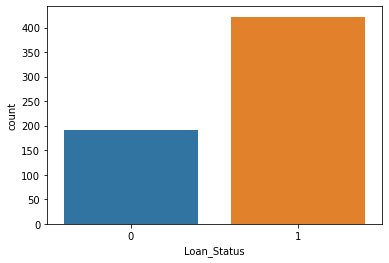

In [46]:
#plt.figure(figsize=(8,6)
sns.countplot(target)
yes=target.value_counts()[1]/len(target)             # yes pour le pourcentage des targets = 0
no=target.value_counts()[0]/len(target)              # No pour le pourcentage des targets = 1
print(f'pourcentages des credits refusés est:{yes}')
print(f'pourcentages des credits accordés est:{no}')

## credit history pour savoir si la Personne à dejà un credit
- Pour cela on utilise FACEGRID

C:\Users\DEYTA\anaconda3\lib\site-packages\seaborn\axisgrid.py:337: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)
C:\Users\DEYTA\anaconda3\lib\site-packages\seaborn\axisgrid.py:670: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


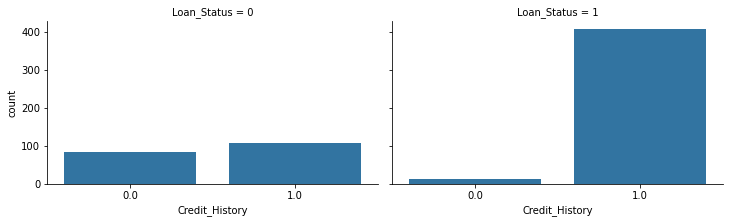

In [37]:
grid=sns.FacetGrid(df,col='Loan_Status',size=3.2, aspect=1.6)
grid.map(sns.countplot,'Credit_History')

- On observe que plus une personne a des antecedant de  credit il a plus de chance d'avoir un autre credit

C:\Users\DEYTA\anaconda3\lib\site-packages\seaborn\axisgrid.py:337: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)
C:\Users\DEYTA\anaconda3\lib\site-packages\seaborn\axisgrid.py:670: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


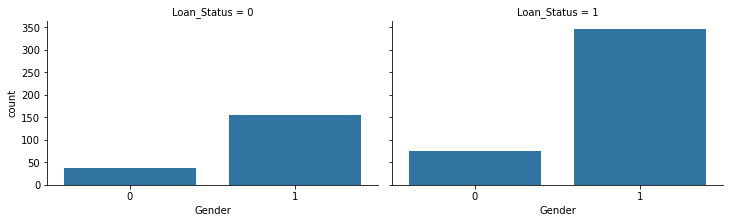

In [38]:
#Sexe
grid=sns.FacetGrid(df,col='Loan_Status',size=3.2, aspect=1.6)
grid.map(sns.countplot,'Gender')

- On observe également que le credit accepté sont plus des hommes que de femme

C:\Users\DEYTA\anaconda3\lib\site-packages\seaborn\axisgrid.py:337: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)
C:\Users\DEYTA\anaconda3\lib\site-packages\seaborn\axisgrid.py:670: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


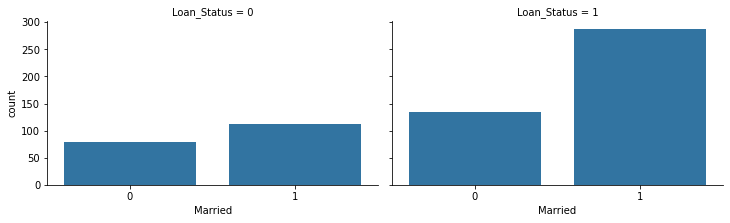

In [39]:
#statut marital
grid=sns.FacetGrid(df,col='Loan_Status',size=3.2, aspect=1.6)
grid.map(sns.countplot,'Married')

- Dans les credits acceptés on a plus de de marié que de celibateur

C:\Users\DEYTA\anaconda3\lib\site-packages\seaborn\axisgrid.py:337: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)
C:\Users\DEYTA\anaconda3\lib\site-packages\seaborn\axisgrid.py:670: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


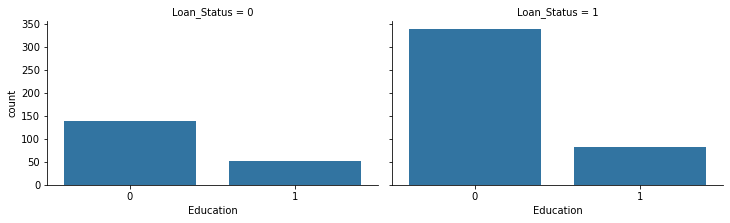

In [41]:
#niveau d'etude
grid=sns.FacetGrid(df,col='Loan_Status',size=3.2, aspect=1.6)
grid.map(sns.countplot,'Education')

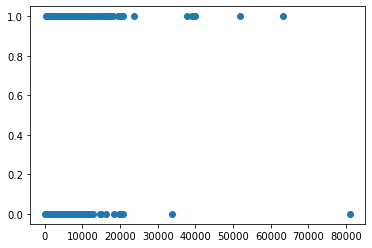

In [42]:
# Revenu du demandeur
plt.scatter(df['ApplicantIncome'],df['Loan_Status'])

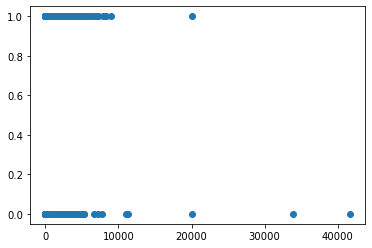

In [43]:
plt.scatter(df['CoapplicantIncome'],df['Loan_Status'])

In [44]:
df.groupby('Loan_Status').median()

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
Loan_Status,,,,,,,,,,,
0,1.0,1.0,0.0,0.0,0.0,1.0,3833.5,268.0,132.5,360.0,1.0
1,1.0,1.0,0.0,0.0,0.0,1.0,3812.5,1239.5,127.5,360.0,1.0


## Preparation du Modèle

- Division de la base de données en une base de données test et d'entrainement

In [52]:
y=Y.copy()

In [53]:
# on utilise sklearn
# on prend 20% pour l'échantillon test

sss=StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train,test in sss.split(X,y):
    X_train,X_test=X.iloc[train],X.iloc[test]
    y_train,y_test=y.iloc[train],y.iloc[test]
    
print('X_train taille',X_train.shape)
print('X_test taille',X_test.shape)
print('y_train taille',y_train.shape)
print('y_test taille',y_test.shape)

X_train taille (491, 11)
X_test taille (123, 11)
y_train taille (491,)
y_test taille (123,)


## On va evaluer trois modèle d'algorithme:on est dans un problème de classification
- Regression logistique(Logisitic Regression)
- KNN
- DecissionTree

In [60]:
models={
    'LogisticRegression':LogisticRegression(random_state=42),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(max_depth=1,random_state=42)  
}
#La fonction de précision
def accu(y_true,y_pred,retu=False):
    acc=accuracy_score(y_true,y_pred)
    if retu:
        return acc
    else:
        print(f'la precision du modèle est:{acc}')

#La fonction d'application des modèles
def train_test_eval(models,X_train,y_train,X_test,y_test):
    for name,model in models.items():
        print(name,':')
        model.fit(X_train,y_train)
        accu(y_test,model.predict(X_test))
        print('-'*30)

train_test_eval(models,X_train,y_train,X_test,y_test)
    


LogisticRegression :
la precision du modèle est:0.8536585365853658
------------------------------
KNeighborsClassifier :
la precision du modèle est:0.6504065040650406
------------------------------
DecisionTreeClassifier :
la precision du modèle est:0.8455284552845529
------------------------------


C:\Users\DEYTA\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Le meilleur modèle est la regression logistique

In [61]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status'],
      dtype='object')

On choisit 5 variables pertinents pour notre modèle

In [67]:
X_2=X[['Credit_History', 'Married','CoapplicantIncome']]
X_2

,Credit_History,Married,CoapplicantIncome
0,1.0,0,0.0
1,1.0,1,1508.0
2,1.0,1,0.0
3,1.0,1,2358.0
4,1.0,0,0.0
...,...,...,...
609,1.0,0,0.0
610,1.0,1,0.0
611,1.0,1,240.0
612,1.0,1,0.0


In [68]:

# on utilise sklearn
# on prend 20% dans la nouvelle base de donnée pour l'échantillon test

sss=StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train,test in sss.split(X_2,y):
    X_train,X_test=X_2.iloc[train],X_2.iloc[test]
    y_train,y_test=y.iloc[train],y.iloc[test]
    
print('X_train taille',X_train.shape)
print('X_test taille',X_test.shape)
print('y_train taille',y_train.shape)
print('y_test taille',y_test.shape)

train_test_eval(models,X_train,y_train,X_test,y_test)
    

X_train taille (491, 3)
X_test taille (123, 3)
y_train taille (491,)
y_test taille (123,)
LogisticRegression :
la precision du modèle est:0.8536585365853658
------------------------------
KNeighborsClassifier :
la precision du modèle est:0.6991869918699187
------------------------------
DecisionTreeClassifier :
la precision du modèle est:0.8455284552845529
------------------------------


## Deploiement

In [69]:
#Appliquer la regression logistique sur notre base de donnée
Classifier=LogisticRegression()
Classifier.fit(X_2,y)

LogisticRegression()

In [72]:
#Enregistrer le modèle pour le deploiement
pe.dump(Classifier,open('model.pkl','wb'))